# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
data = pd.read_csv("Aviation_data_cleaned.csv")
data.head(4)

,event.id,investigation.type,accident.number,event.date,location,country,latitude,longitude,airport.code,airport.name,...,publication.date,total.onboard,aircraft.destroyed,total.passengers,fatal.injury.rate,serious.injury.rate,total.harm.rate,destroyed.flag,destruction.risk,aircraft.id
0,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,01-01-1982,2.0,0,2.0,0.0,0.0,0.0,0,0,CESSNA_140
1,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,01-01-1982,2.0,0,2.0,0.0,0.0,0.0,0,0,CESSNA_401B
2,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,02-01-1983,1.0,1,1.0,0.0,0.0,0.0,1,1,BELLANCA_17-30A
3,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,02-01-1983,1.0,1,1.0,1.0,0.0,1.0,1,1,CESSNA_R172K


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
data["aircraft.size"] = data["total.passengers"].apply(
    lambda x: "SMALL" if x <= 20 else "LARGE"
)

In [6]:
data["aircraft.size"].value_counts(normalize=True) * 100

aircraft.size
SMALL    97.708965
LARGE     2.291035
Name: proportion, dtype: float64

In [10]:
data["fatal.rate"] = data["total.fatal.injuries"] / data["total.passengers"]
data["serious.rate"] = data["total.serious.injuries"] / data["total.passengers"]
data["destruction"] = (data["aircraft.damage"] == "Destroyed").astype(int)

In [28]:
data.columns

Index(['event.id', 'investigation.type', 'accident.number', 'event.date',
       'location', 'country', 'latitude', 'longitude', 'airport.code',
       'airport.name', 'injury.severity', 'aircraft.damage',
       'aircraft.category', 'registration.number', 'make', 'model',
       'amateur.built', 'number.of.engines', 'engine.type', 'far.description',
       'purpose.of.flight', 'air.carrier', 'total.fatal.injuries',
       'total.serious.injuries', 'total.minor.injuries', 'total.uninjured',
       'weather.condition', 'report.status', 'publication.date',
       'total.onboard', 'aircraft.destroyed', 'total.passengers',
       'fatal.injury.rate', 'serious.injury.rate', 'total.harm.rate',
       'destroyed.flag', 'destruction.risk', 'aircraft.id', 'aircraft.size',
       'fatal.rate', 'serious.rate', 'destruction', 'injury.risk'],
      dtype='object')

In [13]:
valid_ids = data["aircraft.id"].value_counts()
valid_ids = valid_ids[valid_ids >= 30].index

df_filtered = data[data["aircraft.id"].isin(valid_ids)]

In [14]:
aircraft_stats = df_filtered.groupby(["aircraft.size", "aircraft.id"]).agg({
    "fatal.rate": "mean",
    "serious.rate": "mean",
    "destruction": "mean",
    "aircraft.id": "count"
}).rename(columns={"aircraft.id": "n_accidents"})

In [15]:
small_aircraft = aircraft_stats.loc["SMALL"]

In [16]:
small_aircraft[small_aircraft["n_accidents"] >= 30] \
    .sort_values(["fatal.rate", "destruction"]) \
    .head(10)

,fatal.rate,serious.rate,destruction,n_accidents
aircraft.id,,,,
CESSNA_180J,0.000000,0.031250,0.000000,32
PIPER_PA-22-160,0.000000,0.138095,0.028571,35
CESSNA_180H,0.011429,0.053333,0.000000,35
CESSNA_172RG,0.022951,0.072131,0.049180,61
CESSNA_195,0.025000,0.045833,0.025000,40
BOEING_A75N1(PT17),0.033333,0.100000,0.033333,30
GRUMMAN_G-164A,0.035088,0.122807,0.263158,57
CESSNA_180,0.036568,0.078411,0.033755,237
CESSNA_170,0.037037,0.064815,0.061728,81


In [17]:
df_filtered.groupby("aircraft.size")[["fatal.rate", "serious.rate", "destruction"]].mean()

,fatal.rate,serious.rate,destruction
aircraft.size,,,
LARGE,0.109893,0.022432,0.112245
SMALL,0.152979,0.113702,0.117896


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [19]:
data["fatal.rate"] = data["total.fatal.injuries"] / data["total.passengers"]
data["serious.rate"] = data["total.serious.injuries"] / data["total.passengers"]

In [21]:
data["injury.risk"] = data["fatal.rate"] + data["serious.rate"]

In [23]:
small_data = data[data["aircraft.size"] == "SMALL"]
large_data = data[data["aircraft.size"] == "LARGE"]

In [24]:
small_make_risk = small_data.groupby("make")["injury.risk"].mean()
small_make_risk = small_make_risk.sort_values().head(15)

In [25]:
large_make_risk = large_data.groupby("make")["injury.risk"].mean()
large_make_risk = large_make_risk.sort_values().head(15)

In [26]:
comparison = pd.DataFrame({
    "SMALL": small_make_risk,
    "LARGE": large_make_risk
})

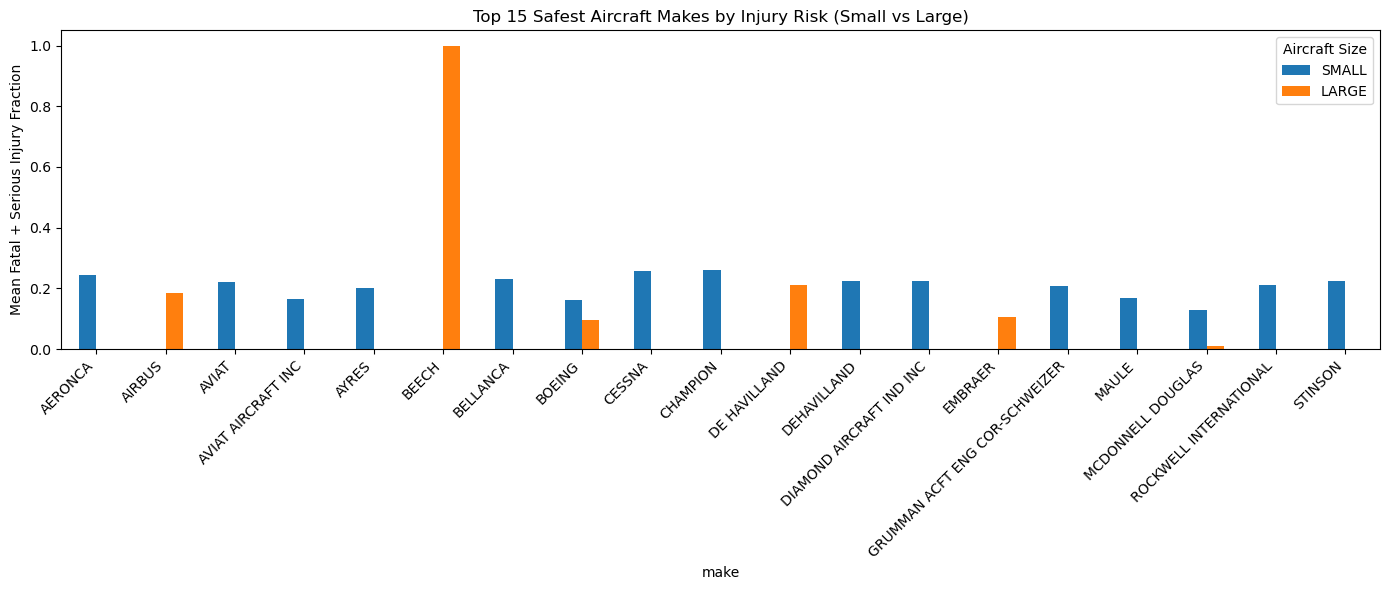

In [27]:

comparison.plot(kind="bar", figsize=(14,6))
plt.title("Top 15 Safest Aircraft Makes by Injury Risk (Small vs Large)")
plt.ylabel("Mean Fatal + Serious Injury Fraction")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Aircraft Size")
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [31]:
top10_small_makes = (
    small_data
    .groupby("make")["injury.risk"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [35]:
plot_data = small_data[small_data["make"].isin(top10_small_makes)]

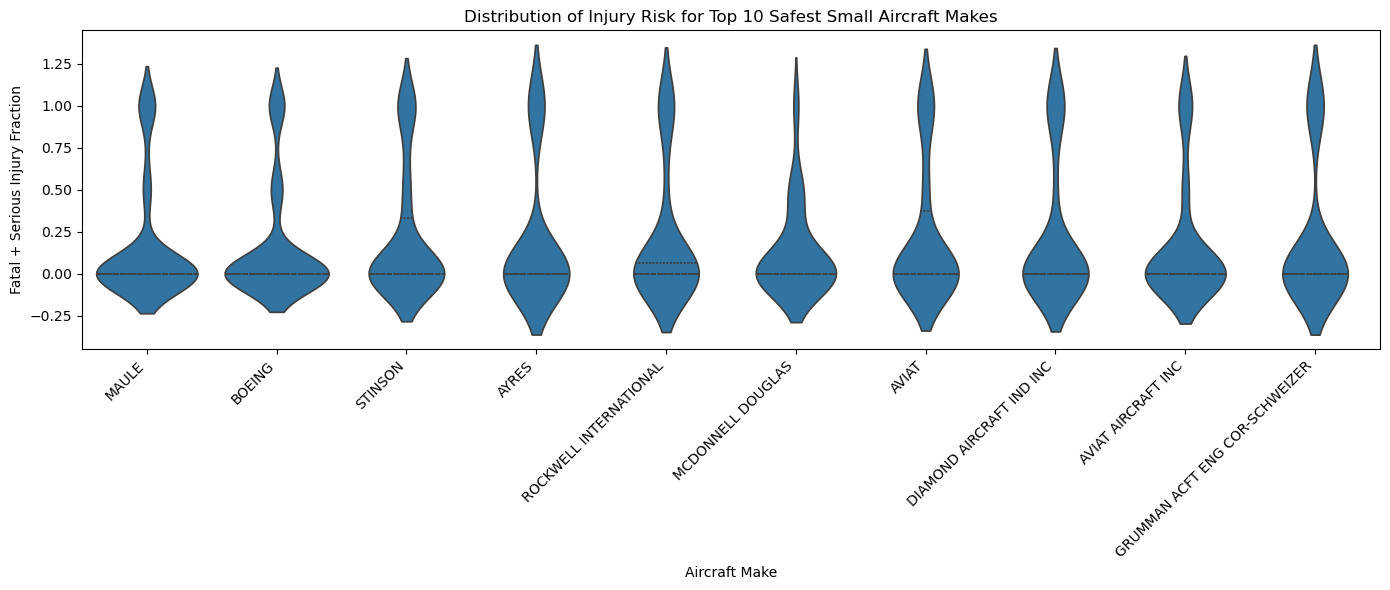

In [38]:
plt.figure(figsize=(14,6))

sns.violinplot(
    data=plot_data,
    x="make",
    y="injury.risk",
    inner="quartile"
)

plt.title("Distribution of Injury Risk for Top 10 Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal + Serious Injury Fraction")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [39]:
top10_large_makes = (
    large_data
    .groupby("make")["injury.risk"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [40]:
plot_data = large_data[large_data["make"].isin(top10_large_makes)].copy()

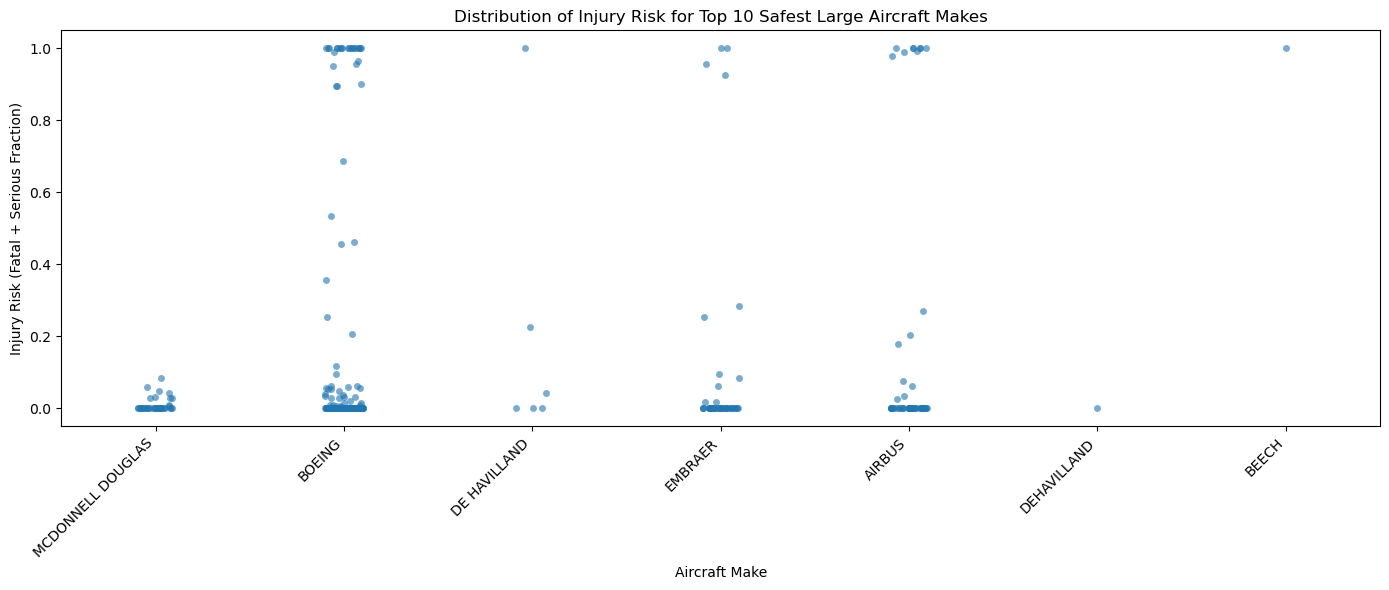

In [41]:
plt.figure(figsize=(14,6))

sns.stripplot(
    data=plot_data,
    x="make",
    y="injury.risk",
    jitter=True,
    alpha=0.6
)

plt.title("Distribution of Injury Risk for Top 10 Safest Large Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Injury Risk (Fatal + Serious Fraction)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [42]:
small_destruction = (
    small_data
    .groupby("make")["destruction.risk"]
    .mean()
    .sort_values()
    .head(15)
)

In [43]:
large_destruction = (
    large_data
    .groupby("make")["destruction.risk"]
    .mean()
    .sort_values()
    .head(15)
)

In [44]:
small_destruction_df = small_destruction.reset_index()
small_destruction_df.columns = ["make", "mean_destruction_risk"]

large_destruction_df = large_destruction.reset_index()
large_destruction_df.columns = ["make", "mean_destruction_risk"]

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Recommendation
Based on both injury fraction and destruction fraction, the safest manufacturers are those that consistently appear in the lowest-risk groups across both metrics.
 ### Conclusion
 * small aircraft tend to exhibit moree safety performance
 * Large aircraft show higher viability in both injury and destructions

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [55]:
large_data = data[data["aircraft.size"] == "LARGE"]

In [56]:
valid_makes = large_data["make"].value_counts()
valid_makes = valid_makes[valid_makes >= 10].index

large_data = large_data[large_data["make"].isin(valid_makes)]

In [57]:
large_make_mean = (
    large_data
    .groupby("make")["injury.risk"]
    .mean()
    .sort_values()
)

In [58]:
top15_large = large_make_mean.head(15)

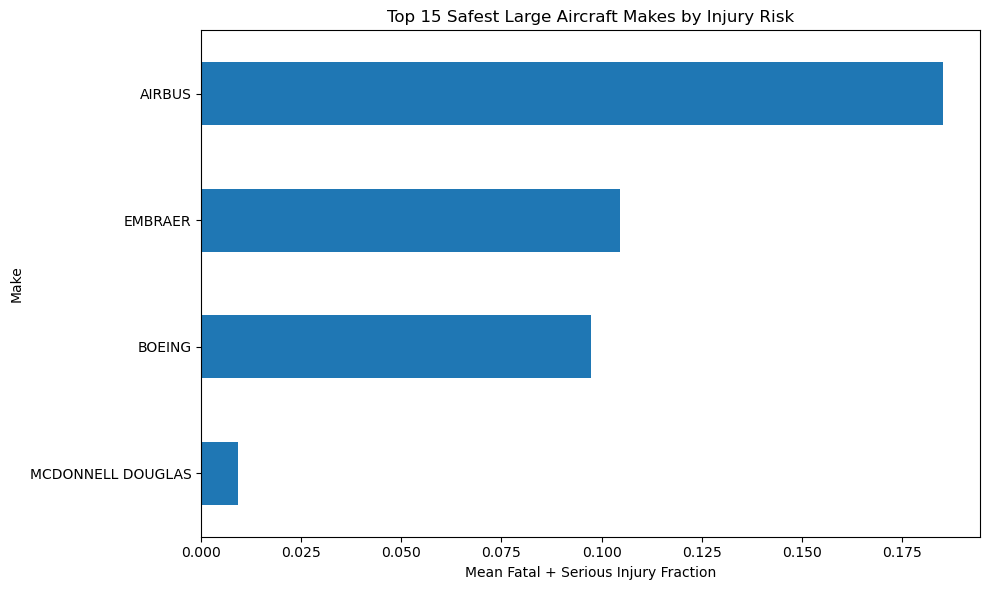

In [65]:
plt.figure(figsize=(10,6))

top15_large.plot(kind="barh")

plt.title("Top 15 Safest Large Aircraft Makes by Injury Risk")
plt.xlabel("Mean Fatal + Serious Injury Fraction")
plt.ylabel("Make")

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [61]:
valid_makes = small_data["make"].value_counts()
valid_makes = valid_makes[valid_makes >= 10].index

small_data = small_data[small_data["make"].isin(valid_makes)]

In [62]:
small_make_mean = (
    small_data
    .groupby("make")["injury.risk"]
    .mean()
    .sort_values()
)

In [63]:
top10_small = small_make_mean.head(10)

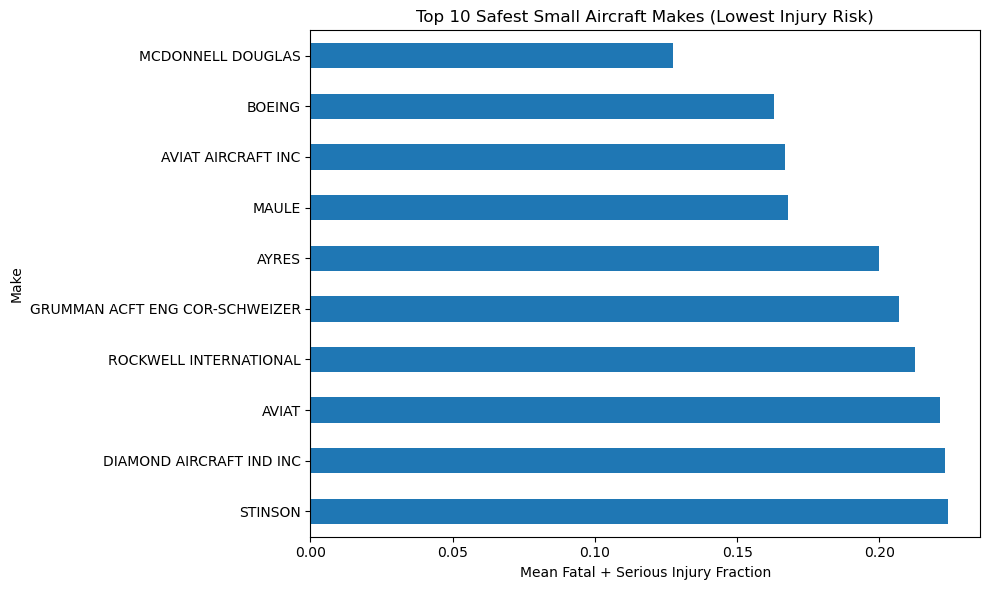

In [64]:
plt.figure(figsize=(10,6))

top10_small.plot(kind="barh")

plt.title("Top 10 Safest Small Aircraft Makes (Lowest Injury Risk)")
plt.xlabel("Mean Fatal + Serious Injury Fraction")
plt.ylabel("Make")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Small aircraft are generally more predictable in safety performance, with tighter injury risk distributions.
Large aircraft show greater dispersion in injury outcomes, meaning safety is less uniform and more dependent on operational conditions.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [66]:
weather_summary = (
    data.groupby("weather.condition")[["injury.risk"]]
    .mean()
    .sort_values("injury.risk", ascending=False)
)

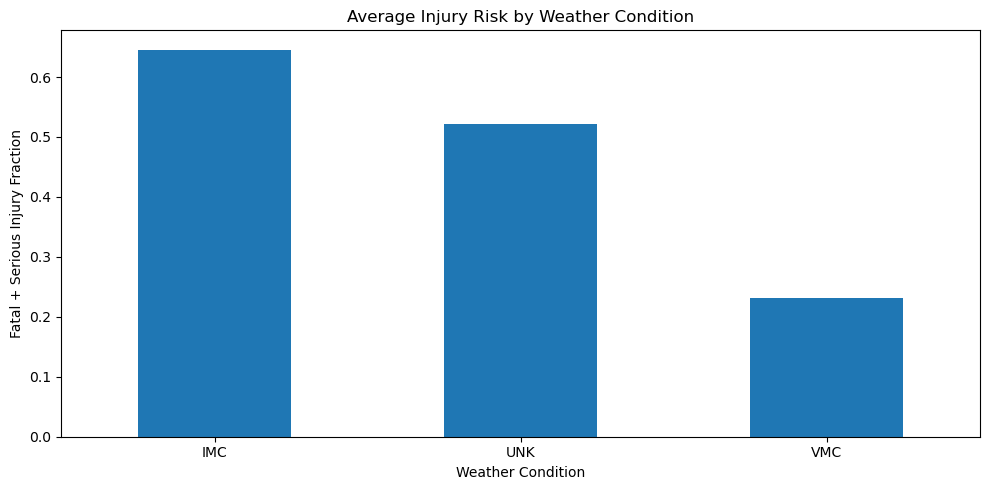

In [67]:


plt.figure(figsize=(10,5))

weather_summary["injury.risk"].plot(kind="bar")

plt.title("Average Injury Risk by Weather Condition")
plt.ylabel("Fatal + Serious Injury Fraction")
plt.xlabel("Weather Condition")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [68]:
engine_summary = (
    data.groupby("engine.type")[["injury.risk"]]
    .mean()
    .sort_values("injury.risk", ascending=False)
)

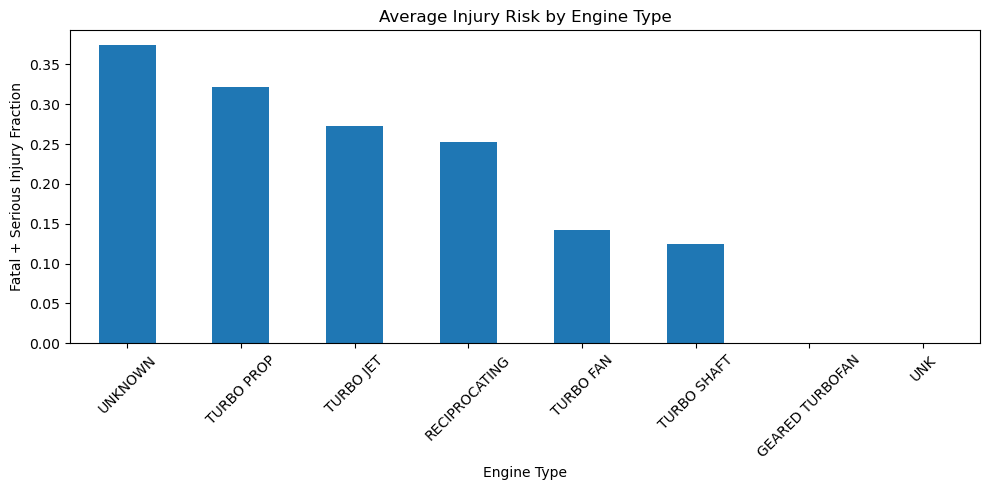

In [69]:
plt.figure(figsize=(10,5))

engine_summary["injury.risk"].plot(kind="bar")

plt.title("Average Injury Risk by Engine Type")
plt.ylabel("Fatal + Serious Injury Fraction")
plt.xlabel("Engine Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()